In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

In [3]:
df["TotalPrice"].sum()

17374804.268000003

In [4]:
df["StockCode"].duplicated().sum()

774794

In [5]:
df['InvoiceDate'].max()

'2011-12-09 12:50:00'

In [6]:
snapshot_date = pd.to_datetime(df["InvoiceDate"]).max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [7]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - pd.to_datetime(x).max()).days,
    "Invoice": "nunique",
    "TotalPrice": "sum"
}).reset_index()

In [8]:
rfm.columns = [
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [9]:
rfm["Recency"].describe()

count    5878.000000
mean      201.331916
std       209.338707
min         1.000000
25%        26.000000
50%        96.000000
75%       380.000000
max       739.000000
Name: Recency, dtype: float64

In [10]:
rfm["Monetary"].describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: Monetary, dtype: float64

In [11]:
rfm["Frequency"].describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Frequency, dtype: float64

In [12]:
# customer with most orders
top_customer = rfm.sort_values("Frequency", ascending=False).head(1)
print(top_customer)

      CustomerID  Recency  Frequency   Monetary
2538     14911.0        1        398  291420.81


In [13]:
#largest spender and average spender
top_spender = rfm.sort_values("Monetary", ascending=False).head(1)
average_spender = rfm["Monetary"].mean()
print(f"Top spender:\n{top_spender}\n")
print(f"Average spender: {average_spender:.2f}")

Top spender:
      CustomerID  Recency  Frequency   Monetary
5692     18102.0        1        145  580987.04

Average spender: 2955.90


In [14]:
#checking negative recency values
negative_recency = rfm[rfm["Recency"] < 0]
print(f"Negative recency values:\n{negative_recency}")

Negative recency values:
Empty DataFrame
Columns: [CustomerID, Recency, Frequency, Monetary]
Index: []


In [15]:
# any zeroes in freuency or monetary
zero_frequency = rfm[rfm["Frequency"] == 0]
zero_monetary = rfm[rfm["Monetary"] == 0]
print(f"Zero frequency values:\n{zero_frequency}\n")
print(f"Zero monetary values:\n{zero_monetary}")

Zero frequency values:
Empty DataFrame
Columns: [CustomerID, Recency, Frequency, Monetary]
Index: []

Zero monetary values:
Empty DataFrame
Columns: [CustomerID, Recency, Frequency, Monetary]
Index: []


In [16]:
#negative monetary values
negative_monetary = rfm[rfm["Monetary"] < 0]
print(f"Negative monetary values:\n{negative_monetary}")

Negative monetary values:
Empty DataFrame
Columns: [CustomerID, Recency, Frequency, Monetary]
Index: []


In [17]:
rfm.shape

(5878, 4)

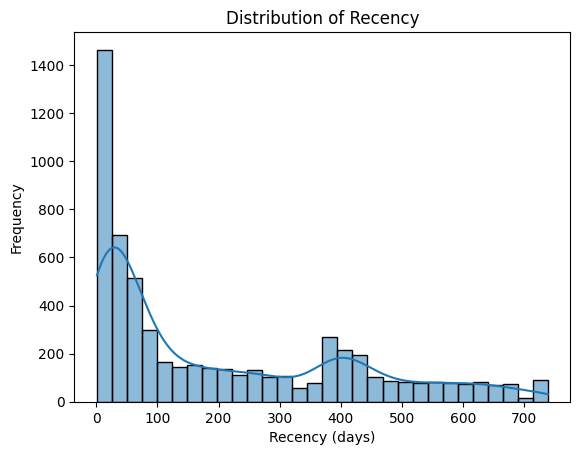

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(rfm["Recency"], bins=30, kde=True)
plt.title("Distribution of Recency")
plt.xlabel("Recency (days)")
plt.ylabel("Frequency")
plt.show()

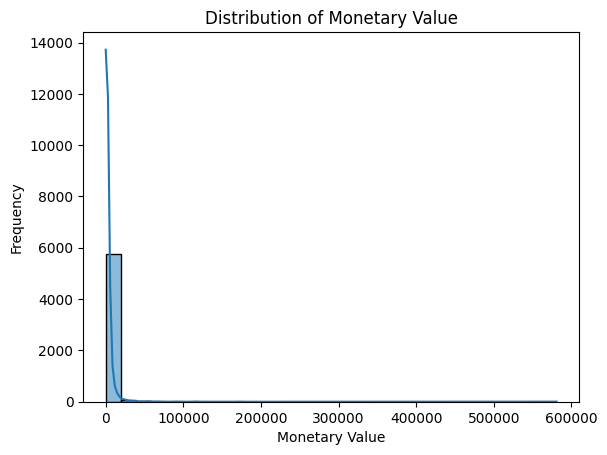

In [19]:
#plot to check the totalrevenue distribution and change x scale 
sns.histplot(rfm["Monetary"], bins=30, kde=True)
plt.title("Distribution of Monetary Value") 
plt.xlabel("Monetary Value")
plt.ylabel("Frequency")
plt.show()

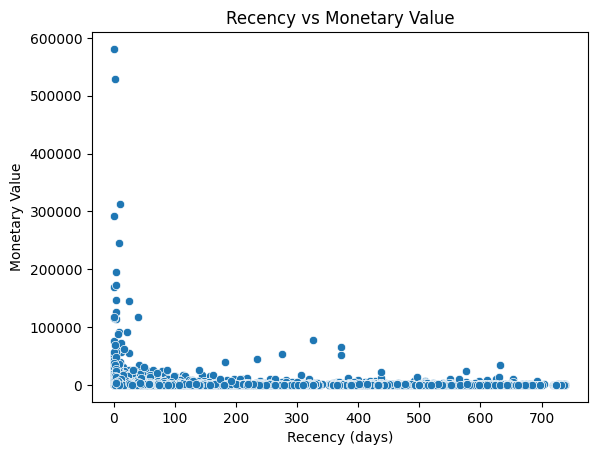

In [20]:
#plot for recency and monetary
sns.scatterplot(data=rfm, x="Recency", y="Monetary")
plt.title("Recency vs Monetary Value")
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.show()

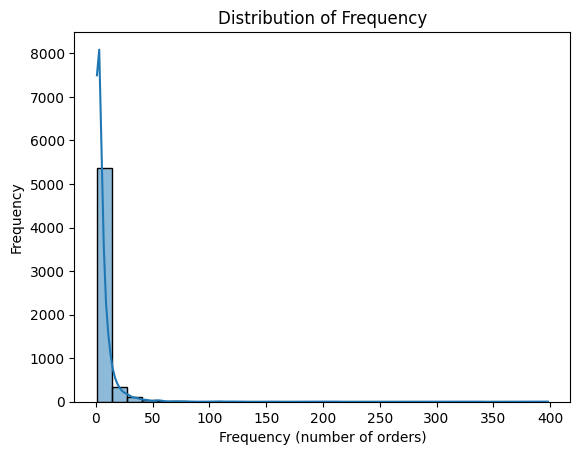

In [21]:
#frequency distribution
sns.histplot(rfm["Frequency"], bins=30, kde=True)
plt.title("Distribution of Frequency")
plt.xlabel("Frequency (number of orders)")
plt.ylabel("Frequency")
plt.show()

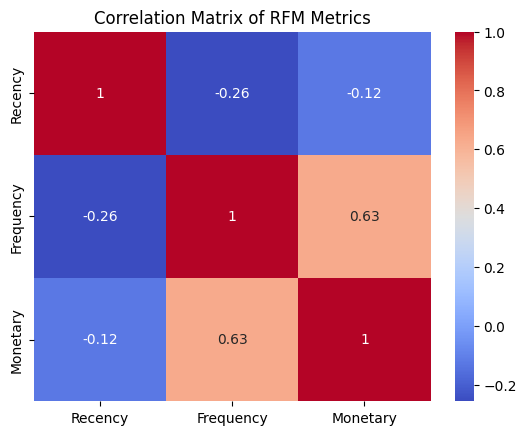

In [22]:
#making correlation matrix
correlation_matrix = rfm[["Recency", "Frequency", "Monetary"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of RFM Metrics")
plt.show()

In [23]:
rfm_copy = rfm.copy()

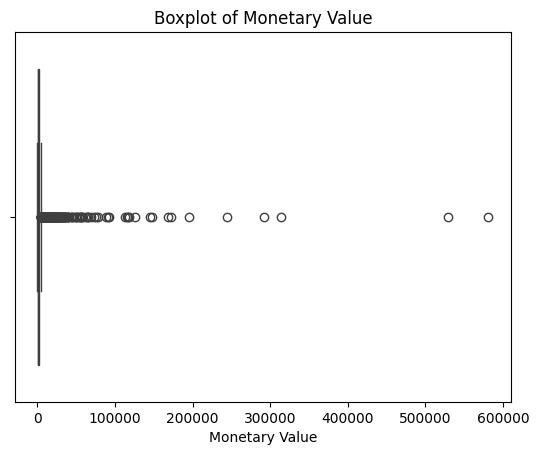

In [24]:
#making a boxplot to check for outliers in monetary value
sns.boxplot(x=rfm["Monetary"])
plt.title("Boxplot of Monetary Value")
plt.xlabel("Monetary Value")
plt.show()

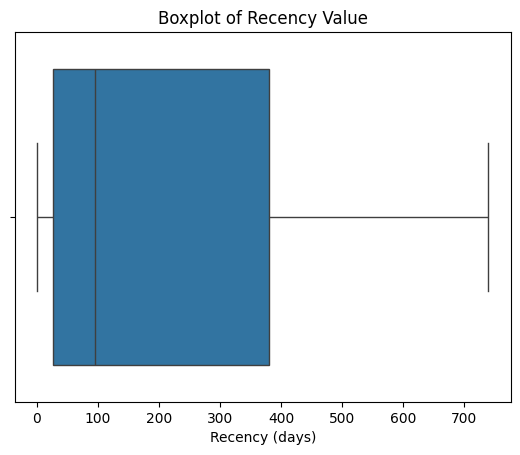

In [25]:
#making a boxplot to check for outliers in Recency value
sns.boxplot(x=rfm["Recency"])
plt.title("Boxplot of Recency Value")
plt.xlabel("Recency (days)")
plt.show()

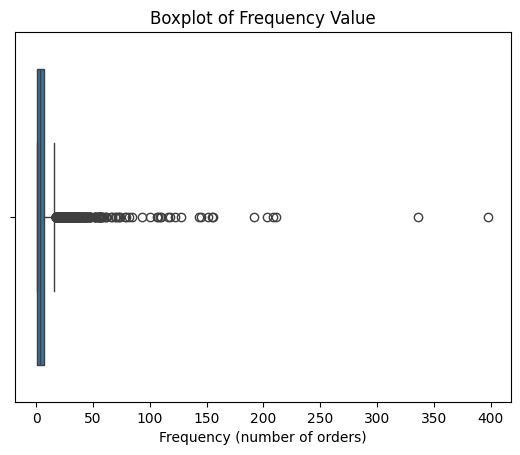

In [26]:
#making a boxplot to check for outliers in frequency value
sns.boxplot(x=rfm["Frequency"])
plt.title("Boxplot of Frequency Value")
plt.xlabel("Frequency (number of orders)")
plt.show()

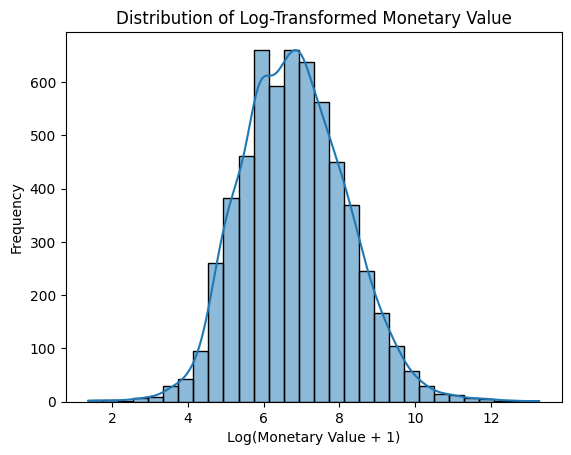

In [27]:
#making log transformation to reduce skewness
import numpy as np
rfm["Monetary_log"] = rfm["Monetary"].apply(lambda x: np.log(x + 1))
sns.histplot(rfm["Monetary_log"], bins=30, kde=True)
plt.title("Distribution of Log-Transformed Monetary Value")
plt.xlabel("Log(Monetary Value + 1)")
plt.ylabel("Frequency")
plt.show()

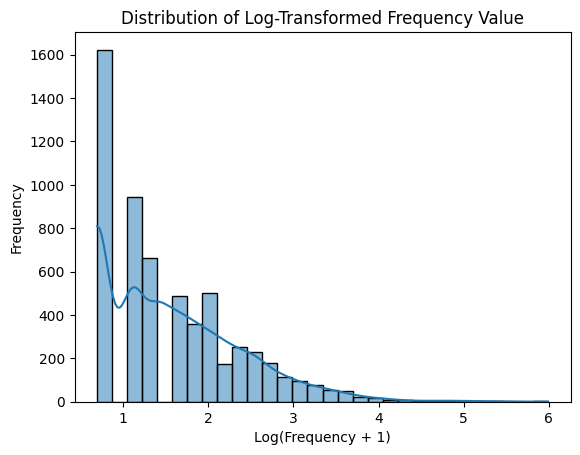

In [28]:
#making log transformation to reduce skewness in frequency
rfm["Frequency_log"] = rfm["Frequency"].apply(lambda x: np.log(x + 1))
sns.histplot(rfm["Frequency_log"], bins=30, kde=True)
plt.title("Distribution of Log-Transformed Frequency Value")
plt.xlabel("Log(Frequency + 1)")
plt.ylabel("Frequency")
plt.show()

In [29]:
# install scikit-learn if missing
%pip install scikit-learn

#scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()   
rfm_scaled = rfm.copy()
rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]] = scaler.fit_transform(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]])
rfm_scaled.head()

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,CustomerID,Recency,Frequency,Monetary,Monetary_log,Frequency_log
0,12346.0,0.595584,12,77556.46,3.206219,1.254496
1,12347.0,-0.952279,8,4921.53,1.215993,0.800166
2,12348.0,-0.603532,5,2019.40,0.573185,0.299207
3,12349.0,-0.871064,4,4428.69,1.139846,0.073946
4,12350.0,0.519146,1,334.40,-0.723024,-1.058146


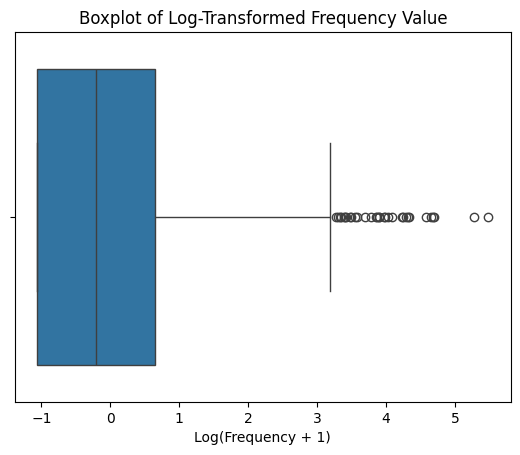

In [30]:
#box plot for frequency_log
sns.boxplot(x=rfm_scaled["Frequency_log"])
plt.title("Boxplot of Log-Transformed Frequency Value")
plt.xlabel("Log(Frequency + 1)")
plt.show()

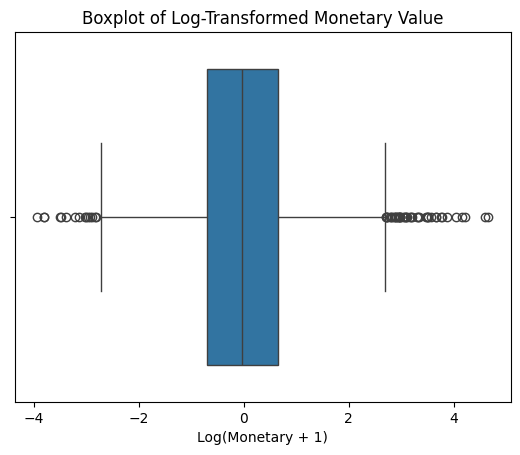

In [31]:
#box plot for monetary_log
sns.boxplot(x=rfm_scaled["Monetary_log"])
plt.title("Boxplot of Log-Transformed Monetary Value")
plt.xlabel("Log(Monetary + 1)")
plt.show()

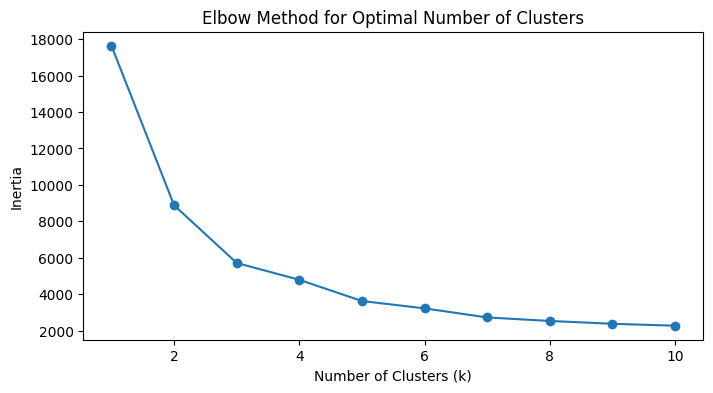

In [32]:
#running elbow method to find optimal number of clusters
from sklearn.cluster import KMeans
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]])
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

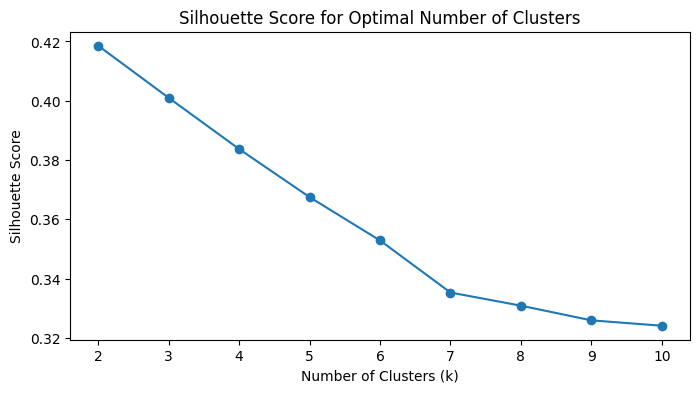

In [33]:
#silhouette score to find optimal number of clusters
from sklearn.metrics import silhouette_score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]])
    silhouette_avg = silhouette_score(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]], cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title("Silhouette Score for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [34]:
#recording the silhouette scores for k=2 to k=10
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]])
    silhouette_avg = silhouette_score(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]], cluster_labels)
    print(f"Silhouette Score for k={k}: {silhouette_avg:.4f}")

Silhouette Score for k=2: 0.4185
Silhouette Score for k=3: 0.4010
Silhouette Score for k=4: 0.3837
Silhouette Score for k=5: 0.3675
Silhouette Score for k=6: 0.3529
Silhouette Score for k=7: 0.3353
Silhouette Score for k=8: 0.3309
Silhouette Score for k=9: 0.3260
Silhouette Score for k=10: 0.3241


In [35]:
#recording the elbow method inertia values for k=1 to k=10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]])
    print(f"Inertia for k={k}: {kmeans.inertia_:.4f}")

Inertia for k=1: 17634.0000
Inertia for k=2: 8881.0825
Inertia for k=3: 5716.0466
Inertia for k=4: 4790.8060
Inertia for k=5: 3628.3565
Inertia for k=6: 3225.0129
Inertia for k=7: 2726.3748
Inertia for k=8: 2534.2157
Inertia for k=9: 2379.4034
Inertia for k=10: 2272.8466


In [36]:
#createing final kmeans model with k=4
kmeans_final = KMeans(n_clusters=4, random_state=42)    
rfm_scaled["Cluster"] = kmeans_final.fit_predict(rfm_scaled[["Recency", "Frequency_log", "Monetary_log"]])
rfm_scaled.head()

,CustomerID,Recency,Frequency,Monetary,Monetary_log,Frequency_log,Cluster
0,12346.0,0.595584,12,77556.46,3.206219,1.254496,1
1,12347.0,-0.952279,8,4921.53,1.215993,0.800166,1
2,12348.0,-0.603532,5,2019.40,0.573185,0.299207,2
3,12349.0,-0.871064,4,4428.69,1.139846,0.073946,1
4,12350.0,0.519146,1,334.40,-0.723024,-1.058146,3


In [37]:
#make a table to show the average recency, frequency, and monetary value for each cluster
cluster_summary = rfm_scaled.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency_log": "mean",
    "Monetary_log": "mean"
}).reset_index()
cluster_summary

,Cluster,Recency,Frequency_log,Monetary_log
0,0,0.860325,-0.147696,0.103391
1,1,-0.729186,1.263012,1.158909
2,2,-0.609633,-0.381826,-0.325940
3,3,1.404648,-0.962748,-1.096933


In [38]:
#creating final clusters with k=5
kmeans_final_5 = KMeans(n_clusters=5, random_state=42)
rfm_scaled["Cluster_5"] = kmeans_final_5.fit_predict(rfm_scaled
[["Recency", "Frequency_log", "Monetary_log"]])

In [39]:
#creating table to show the average recency, frequency, and monetary value for each cluster with k=5
cluster_summary_5 = rfm_scaled.groupby("Cluster_5").agg({   
    "Recency": "mean",
    "Frequency_log": "mean",
    "Monetary_log": "mean"
}).reset_index()
cluster_summary_5

,Cluster_5,Recency,Frequency_log,Monetary_log
0,0,0.932546,-0.193834,0.065020
1,1,-0.782138,1.855422,1.618962
2,2,-0.515153,-0.681384,-0.659945
3,3,1.505959,-0.966768,-1.104548
4,4,-0.656122,0.468505,0.515385


In [40]:
#making cluster with original values for k=4
kmeans_final_original = KMeans(n_clusters=4, random_state=42)
rfm["Cluster_original"] = kmeans_final_original.fit_predict(rfm[["Recency", "Frequency", "Monetary"]])


In [41]:
#now creating table to show the average recency, frequency, and monetary value for each cluster with original values
cluster_summary_original = rfm.groupby("Cluster_original").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).reset_index()
cluster_summary_original

,Cluster_original,Recency,Frequency,Monetary
0,0,202.922998,5.522688,2026.892488
1,1,1.500000,148.000000,554794.780000
2,2,6.875000,111.625000,209686.235000
3,3,55.300000,72.980000,55905.286660


In [42]:
#creating cluser with original values for k=5
kmeans_final_original_5 = KMeans(n_clusters=5, random_state=42)
rfm["Cluster_original_5"] = kmeans_final_original_5.fit_predict(rfm[["Recency", "Frequency", "Monetary"]])

In [43]:
#making table to show the average recency, frequency, and monetary value for each cluster with original values for k=5
cluster_summary_original_5 = rfm.groupby("Cluster_original_5").agg({ 
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).reset_index()
cluster_summary_original_5

,Cluster_original_5,Recency,Frequency,Monetary
0,0,211.535234,4.452960,1393.058355
1,1,1.500000,148.000000,554794.780000
2,2,6.875000,111.625000,209686.235000
3,3,60.896552,87.620690,71686.173207
4,4,50.726727,26.189189,14530.469973


In [44]:
#adding cluster labels to original rfm table and  human readable labels for each cluster and count customers in each cluster
rfm["Cluster_Label"] = rfm["Cluster_original_5"].map({
    0: "Dormant Customers",
    1: "VIP Customers",
    2: "High-Value Customers",
    3: "Loyal Customers",
    4: "Regular Customers"
})



In [45]:
rfm["Cluster_Label"].value_counts()

Cluster_Label
Dormant Customers       5506
Regular Customers        333
Loyal Customers           29
High-Value Customers       8
VIP Customers              2
Name: count, dtype: int64

In [46]:
#saving the rfm table with cluster labels to a csv file
rfm.to_csv("../data/processed/rfm_with_clusters.csv", index=False)

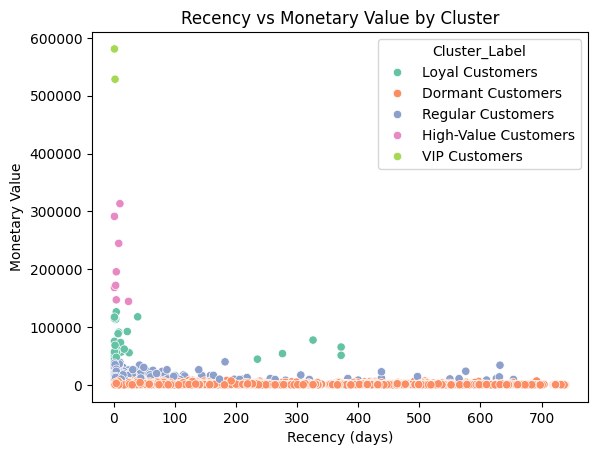

In [47]:
#graph for recency and monetary with cluster labels
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster_Label", palette="Set2")
plt.title("Recency vs Monetary Value by Cluster")   
plt.xlabel("Recency (days)")
plt.ylabel("Monetary Value")
plt.show()

In [48]:
#creating table to show the average recency, frequency, and monetary value for each cluster with k=5
cluster_summary_5 = rfm.groupby("Cluster_Label").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
}).reset_index()
cluster_summary_5

,Cluster_Label,Recency,Frequency,Monetary
0,Dormant Customers,211.535234,4.452960,1393.058355
1,High-Value Customers,6.875000,111.625000,209686.235000
2,Loyal Customers,60.896552,87.620690,71686.173207
3,Regular Customers,50.726727,26.189189,14530.469973
4,VIP Customers,1.500000,148.000000,554794.780000


In [49]:
rfm['Recency'].describe()

count    5878.000000
mean      201.331916
std       209.338707
min         1.000000
25%        26.000000
50%        96.000000
75%       380.000000
max       739.000000
Name: Recency, dtype: float64

In [50]:
#median, 75th, 90th, 95th percentiles for recency
recency_median = rfm['Recency'].median()
recency_75th = rfm['Recency'].quantile(0.75)    
recency_90th = rfm['Recency'].quantile(0.90)
recency_95th = rfm['Recency'].quantile(0.95)
print(f"Recency Median: {recency_median}")
print(f"Recency 75th Percentile: {recency_75th}")
print(f"Recency 90th Percentile: {recency_90th}")
print(f"Recency 95th Percentile: {recency_95th}")

Recency Median: 96.0
Recency 75th Percentile: 380.0
Recency 90th Percentile: 535.0
Recency 95th Percentile: 625.0


In [51]:
#checking for churned customers with recency greater than 90th percentile
churned_customers = rfm[rfm['Recency'] > rfm['Recency'].quantile(0.90)]
print(f"Number of churned customers (Recency > 90th percentile): {churned_customers.shape[0]}")

Number of churned customers (Recency > 90th percentile): 587


In [52]:
#create churn label based on recency greater than 75 percentile
rfm['Churn'] = (rfm['Recency'] > rfm['Recency'].quantile(0.75)).astype(int)

In [53]:
rfm['Churn'].value_counts()

Churn
0    4419
1    1459
Name: count, dtype: int64

In [54]:
#creating model to predict churn based on frequency, and monetary value
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = rfm[["Frequency", "Monetary_log"]]
y = rfm["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [63]:
rfm["churn_probability"] = model.predict_proba(
    X
)[:, 1]

In [64]:
print(
    rfm[
        [
            "CustomerID",
            "Churn",
            "churn_probability"
        ]
    ].head()
)

   CustomerID  Churn  churn_probability
0     12346.0      0           0.004696
1     12347.0      0           0.037968
2     12348.0      0           0.117543
3     12349.0      0           0.123847
4     12350.0      0           0.450300


In [65]:
rfm["churn_probability"].describe()

count    5.878000e+03
mean     2.502488e-01
std      1.842178e-01
min      2.727897e-55
25%      7.185548e-02
50%      2.419199e-01
75%      4.174882e-01
max      7.722820e-01
Name: churn_probability, dtype: float64

In [66]:
churn_export = rfm[
    [
        "CustomerID",
        "churn_probability"
    ]
]

In [69]:
churn_export.to_csv(
    "../data/processed/churn_probabilities.csv",
    index=False
)

In [55]:
#evaluating the model
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,f1_score,precision_score, recall_score
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       881
           1       0.58      0.26      0.36       295

    accuracy                           0.77      1176
   macro avg       0.69      0.60      0.61      1176
weighted avg       0.74      0.77      0.73      1176

Confusion Matrix:
[[826  55]
 [219  76]]


In [56]:
#checking logistic regression coefficients
coefficients = pd.DataFrame({
    "Feature": ["Frequency", "Monetary_log"],
    "Coefficient": model.coef_[0]
})
print(coefficients)


        Feature  Coefficient
0     Frequency    -0.310515
1  Monetary_log    -0.319862


In [57]:
#now creading a model by adding cluster labels as a feature
X_cluster = rfm[["Frequency", "Monetary_log", "Cluster_original_5"]]
y_cluster = rfm["Churn"]
X_train_cluster, X_test_cluster, y_train_cluster, y_test_cluster = train_test_split(X_cluster, y_cluster, test_size=0.2, random_state=42)
model_cluster = LogisticRegression()
model_cluster.fit(X_train_cluster, y_train_cluster)
y_pred_cluster = model_cluster.predict(X_test_cluster)


In [58]:
#evaluating the model
print("Classification Report:")
print(classification_report(y_test_cluster, y_pred_cluster))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cluster, y_pred_cluster))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.86       881
           1       0.57      0.27      0.37       295

    accuracy                           0.77      1176
   macro avg       0.68      0.60      0.61      1176
weighted avg       0.74      0.77      0.73      1176

Confusion Matrix:
[[820  61]
 [214  81]]


In [59]:
#now creating a model by addding recency as a feature
X_recency = rfm[["Frequency", "Monetary_log", "Recency"]]
y_recency = rfm["Churn"]
X_train_recency, X_test_recency, y_train_recency, y_test_recency = train_test_split(X_recency, y_recency, test_size=0.2, random_state=42)
model_recency = LogisticRegression()    
model_recency.fit(X_train_recency, y_train_recency)
y_pred_recency = model_recency.predict(X_test_recency)


In [60]:
#evaluating the model
print("Classification Report:")
print(classification_report(y_test_cluster, y_pred_cluster))
print("Confusion Matrix:")
print(confusion_matrix(y_test_cluster, y_pred_cluster))

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.86       881
           1       0.57      0.27      0.37       295

    accuracy                           0.77      1176
   macro avg       0.68      0.60      0.61      1176
weighted avg       0.74      0.77      0.73      1176

Confusion Matrix:
[[820  61]
 [214  81]]


In [61]:
import joblib

joblib.dump(
    KMeans,
    "../models/customer_segmentation/kmeans.pkl"
)

['../models/customer_segmentation/kmeans.pkl']

In [62]:
joblib.dump(
    model,
    "../models/churn_prediction/logistic_regression.pkl"
)

['../models/churn_prediction/logistic_regression.pkl']